<a href="https://colab.research.google.com/github/cl2832/CHEME-5660-CourseRepository-Fall-2025/blob/main/GTG_performance/CHP_CoolingON_HourDiagnostic_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHP Cooling-ON Hour-of-Day Diagnostic
## Is `cooling_on` concentrated at night? Why?

This notebook checks whether the IAC treatment indicator (ON/OFF) has an unexpected
hour-of-day distribution and diagnoses the most likely cause:

1. **Timezone / timestamp parsing error** -- timestamps may be UTC instead of local
2. **Band selection effect** -- the chosen temperature band may naturally skew toward nighttime
3. **Threshold misclassification** -- a low GPM threshold may label pump recirculation as ON
4. **Partial flow modes** -- multi-modal flow distribution with a low-flow cluster

Uses the same data loading pipeline as `CHP_IAC_CausalRegression_Colab.ipynb`.


---
## Setup


In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats as sp_stats
import warnings, os, sys
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.grid': True, 'grid.alpha': 0.3})
print('Libraries imported')


Libraries imported


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')


Mounted at /content/drive
Google Drive mounted


In [3]:
import os, sys
from google.colab import userdata

!rm -rf /content/insight-chp

token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/cl2832/insight-chp.git /content/insight-chp

sys.path.insert(0, '/content/insight-chp/GTG_performance')

from src.chp_preprocessing import load_and_preprocess
print('Import successful')


Cloning into '/content/insight-chp'...
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 263 (delta 38), reused 10 (delta 3), pack-reused 198 (from 1)
Receiving objects: 100% (263/263), 5.73 MiB | 14.98 MiB/s, done.
Resolving deltas: 100% (143/143), done.
Import successful


---
## Configuration


In [4]:
# ============================================================================
# CONFIG -- all tuneable parameters in one place
# ============================================================================
CONFIG = {
    # Column names
    'timestamp_col':  'TimeStamp',
    'temp_col':       'ambient_air_temp_f',
    'rh_col':         'ambient_rh_pct',
    'flow_col':       'iac_cw_flow_gpm',

    # Temperature band for the main analysis
    'temp_band':      (65, 75),

    # Treatment definition: 'simple', 'deadband', or 'full_vs_off'
    'treatment_mode': 'simple',

    # Thresholds per mode
    'simple_threshold': 50,
    'deadband_on':  60,  'deadband_off':  40,
    'full_on':     800,  'full_off':      20,

    # Timezone handling: 'as_is', 'force_local', or 'force_utc'
    'timezone_mode':  'as_is',
    'local_tz':       'America/New_York',

    # Outputs
    'output_dir':     './outputs',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print('CONFIG set')
for k, v in CONFIG.items():
    print(f'  {k:25s} = {v}')


CONFIG set
  timestamp_col             = TimeStamp
  temp_col                  = ambient_air_temp_f
  rh_col                    = ambient_rh_pct
  flow_col                  = iac_cw_flow_gpm
  temp_band                 = (65, 75)
  treatment_mode            = simple
  simple_threshold          = 50
  deadband_on               = 60
  deadband_off              = 40
  full_on                   = 800
  full_off                  = 20
  timezone_mode             = as_is
  local_tz                  = America/New_York
  output_dir                = ./outputs


---
## Load & Preprocess Data


In [5]:
results = load_and_preprocess(
    data_path='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/'
              'merged_chp_data_jul2025_canonical.xlsx',
    cache_dir='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data',
    power_threshold_mw=11.0,
    filtering_mode='manual',
    show_plots=False,
    cooling_mode='binary',
)

df      = results['df']
df_ct1  = results['df_ct1']
df_ct2  = results['df_ct2']
summary = results['summary']
print(f'df shape: {df.shape}')
print(f'df_ct1: {len(df_ct1):,}  |  df_ct2: {len(df_ct2):,}')


📦 Loading from CACHE: /content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/merged_chp_data_jul2025_canonical.pkl
   ✅ 44,640 rows × 89 columns

CALCULATING PERFORMANCE METRICS

📊 CT1 Metrics:
   ✓ ct1_power_mw
   ✓ ct1_heat_input_mmbtu_h
   ✓ ct1_efficiency_pct (avg: 25.65%, 44,176 valid)

📊 CT2 Metrics:
   ✓ ct2_power_mw
   ✓ ct2_heat_input_mmbtu_h
   ✓ ct2_efficiency_pct (avg: 31.02%, 44,623 valid)

❄️  IAC Status:
   ✓ cooling_on  (BINARY mode, threshold: 50.0 GPM)
     • Flow range: -2.9 – 1172.7 GPM
     • ON:  20,476 records
     • OFF: 24,164 records

OPERATIONAL STATUS SUMMARY
Threshold: 11.0 MW

CT1:  Operating 35,820 (80.2%)  |  Offline 8,820 (19.8%)
CT2:  Operating 44,612 (99.9%)  |  Offline 28 (0.1%)

Combined:
  Both ON:   35,804  (80.2%)
  CT1 only:  16  (0.0%)
  CT2 only:  8,808  (19.7%)
  Both OFF:  12  (0.0%)

SMART FILTERING (INDEPENDENT CT1 & CT2)

🎯 MANUAL MODE: fixed thresholds
   CT1: > 11.0 MW
   CT2: > 11.0 MW

📊 Filtering Results:
  Original:      44,640 rec

---
## Build Treatment Indicator


In [6]:
# ============================================================================
# TREATMENT ASSIGNMENT (reusable for all 3 modes)
# ============================================================================

def assign_treatment(flow, mode, cfg):
    """Return treatment Series D given flow Series and CONFIG."""
    if mode == 'simple':
        return (flow > cfg['simple_threshold']).astype(float)
    elif mode == 'deadband':
        D = pd.Series(np.nan, index=flow.index)
        D[flow >= cfg['deadband_on']]  = 1.0
        D[flow <= cfg['deadband_off']] = 0.0
        return D
    elif mode == 'full_vs_off':
        D = pd.Series(np.nan, index=flow.index)
        D[flow >= cfg['full_on']]  = 1.0
        D[flow <= cfg['full_off']] = 0.0
        return D
    else:
        raise ValueError(f'Unknown treatment mode: {mode}')

print('assign_treatment() defined')


assign_treatment() defined


---
## Timezone Handling & Hour Extraction


In [7]:
# ============================================================================
# TIMEZONE + HOUR COLUMN
# ============================================================================
ts = CONFIG['timestamp_col']
tz_mode = CONFIG['timezone_mode']
local_tz = CONFIG['local_tz']

# Work on full df (used later for band-selection comparison)
for frame_name, frame in [('df', df), ('df_ct1', df_ct1), ('df_ct2', df_ct2)]:
    frame[ts] = pd.to_datetime(frame[ts])

    if tz_mode == 'force_utc':
        if frame[ts].dt.tz is None:
            frame[ts] = frame[ts].dt.tz_localize('UTC')
        frame[ts] = frame[ts].dt.tz_convert(local_tz)
        print(f'  {frame_name}: forced UTC -> {local_tz}')
    elif tz_mode == 'force_local':
        if frame[ts].dt.tz is None:
            frame[ts] = frame[ts].dt.tz_localize(local_tz)
        print(f'  {frame_name}: localized as {local_tz}')
    else:
        print(f'  {frame_name}: timestamps used as-is')

    frame['hour'] = frame[ts].dt.hour
    frame['date'] = frame[ts].dt.date

print(f'\nTimezone mode: {tz_mode}')
print(f'Time range: {df[ts].min()} -> {df[ts].max()}')


  df: timestamps used as-is
  df_ct1: timestamps used as-is
  df_ct2: timestamps used as-is

Timezone mode: as_is
Time range: 2025-07-01 12:00:00 -> 2025-08-01 11:59:00


---
## Step 1 -- Data Snapshot


In [8]:
# ============================================================================
# DATA SNAPSHOT
# ============================================================================
ts = CONFIG['timestamp_col']
key_cols = [ts, CONFIG['temp_col'], CONFIG['rh_col'], CONFIG['flow_col']]

print('=' * 72)
print('DATA SNAPSHOT')
print('=' * 72)
print(f'  Total rows:     {len(df):,}')
print(f'  Time range:     {df[ts].min()} -> {df[ts].max()}')
print(f'  df_ct1 rows:    {len(df_ct1):,}')
print(f'  df_ct2 rows:    {len(df_ct2):,}')

print(f'\n  Column completeness (full df):')
for col in key_cols:
    if col in df.columns:
        pct = df[col].notna().mean() * 100
        print(f'    {col:35s} {pct:6.1f}% complete')
    else:
        print(f'    {col:35s} MISSING!')


DATA SNAPSHOT
  Total rows:     44,640
  Time range:     2025-07-01 12:00:00 -> 2025-08-01 11:59:00
  df_ct1 rows:    35,820
  df_ct2 rows:    44,612

  Column completeness (full df):
    TimeStamp                            100.0% complete
    ambient_air_temp_f                   100.0% complete
    ambient_rh_pct                       100.0% complete
    iac_cw_flow_gpm                      100.0% complete


---
## Step 2 -- Timestamp Sanity Check (Timezone Diagnostic)

If the data is stored in UTC but parsed as local time, the diurnal temperature
cycle will be shifted. We plot temperature vs hour for 1-2 sample days and check
whether the peak occurs in the afternoon (expected) or at night (red flag).


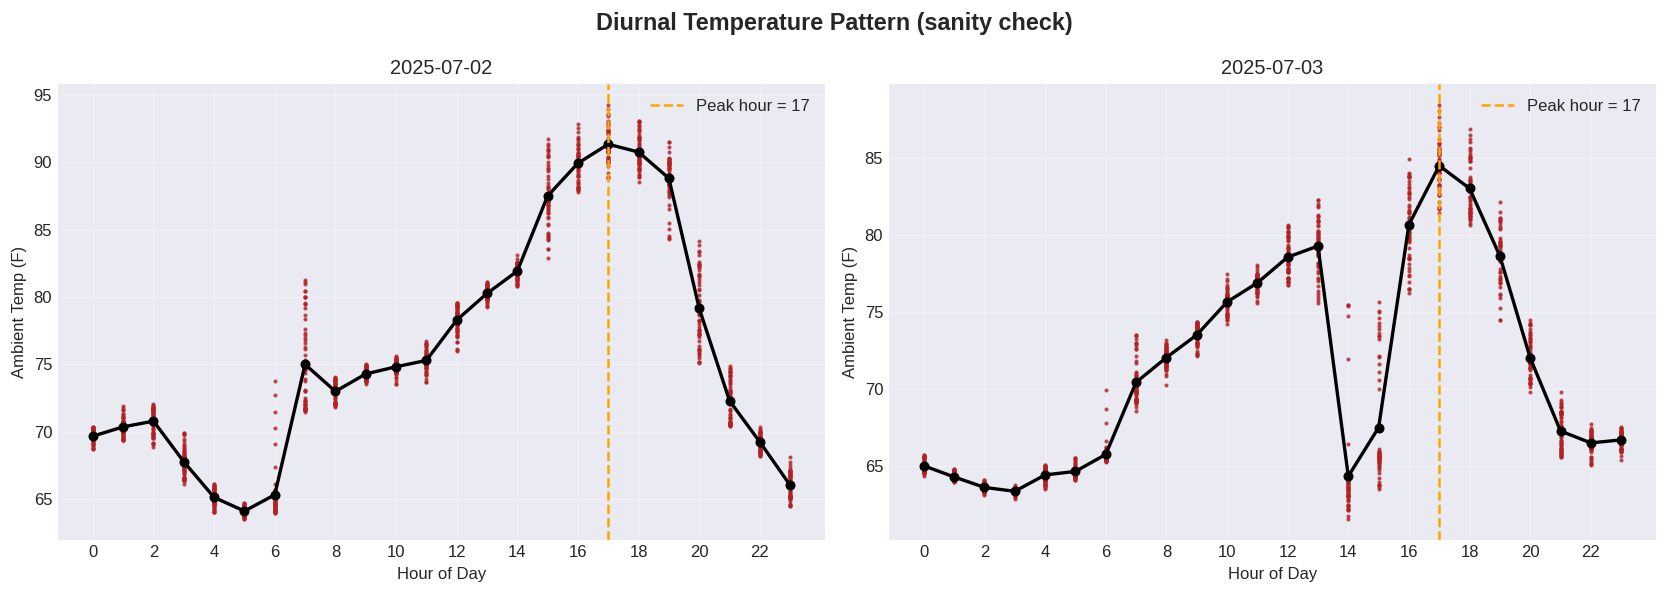


DIAGNOSTIC:
  2025-07-02: Peak at hour 17 -- OK (afternoon peak, timezone looks correct)
  2025-07-03: Peak at hour 17 -- OK (afternoon peak, timezone looks correct)


In [9]:
# ============================================================================
# TIMESTAMP SANITY CHECK -- diurnal temperature pattern
# ============================================================================
temp_col = CONFIG['temp_col']
ts_col   = CONFIG['timestamp_col']

# Pick 2 summer days with the most data
day_counts = df.groupby('date').size()
# Filter to days with temp data and > 100 rows
summer_mask = df.groupby('date')[temp_col].mean()
summer_days = summer_mask[summer_mask > 70].index  # likely summer
if len(summer_days) == 0:
    summer_days = day_counts.nlargest(2).index
else:
    summer_days = day_counts.loc[summer_days].nlargest(2).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
peak_hours = []

for ax, day in zip(axes, summer_days):
    mask = df['date'] == day
    d = df[mask].sort_values(ts_col)
    ax.plot(d['hour'], d[temp_col], '.', markersize=3, alpha=0.7, color='firebrick')

    # Hourly mean
    hmean = d.groupby('hour')[temp_col].mean()
    ax.plot(hmean.index, hmean.values, 'o-', color='black', linewidth=2, markersize=5)

    pk = hmean.idxmax()
    peak_hours.append(pk)
    ax.axvline(pk, color='orange', linestyle='--', linewidth=1.5, label=f'Peak hour = {pk}')

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Ambient Temp (F)')
    ax.set_title(f'{day}')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()

fig.suptitle('Diurnal Temperature Pattern (sanity check)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Diagnostic
print('\nDIAGNOSTIC:')
for day, pk in zip(summer_days, peak_hours):
    if 12 <= pk <= 17:
        print(f'  {day}: Peak at hour {pk} -- OK (afternoon peak, timezone looks correct)')
    elif 0 <= pk <= 6 or pk >= 22:
        print(f'  {day}: Peak at hour {pk} -- WARNING: peak at night!')
        print(f'    >>> Timestamps may be in UTC. Try CONFIG["timezone_mode"] = "force_utc"')
    else:
        print(f'  {day}: Peak at hour {pk} -- unusual, may warrant investigation')


---
## Step 3 -- Overlap Statistics in Temperature Band


In [10]:
# ============================================================================
# OVERLAP STATS in temp band
# ============================================================================
temp_lo, temp_hi = CONFIG['temp_band']
flow_col = CONFIG['flow_col']

overlap_rows = []

for label, frame in [('CT1', df_ct1), ('CT2', df_ct2)]:
    band = frame[frame[temp_col].between(temp_lo, temp_hi)].copy()
    band['D'] = assign_treatment(band[flow_col], CONFIG['treatment_mode'], CONFIG)
    band = band.dropna(subset=['D'])

    n_on  = (band['D'] == 1).sum()
    n_off = (band['D'] == 0).sum()
    n_tot = n_on + n_off

    print(f'{label}  (band {temp_lo}-{temp_hi}F, treatment={CONFIG["treatment_mode"]})')
    print(f'  N = {n_tot:,}  |  ON = {n_on:,} ({n_on/max(n_tot,1)*100:.1f}%)  |  OFF = {n_off:,} ({n_off/max(n_tot,1)*100:.1f}%)')

    overlap_rows.append({'turbine': label, 'band': f'{temp_lo}-{temp_hi}',
                         'treatment_mode': CONFIG['treatment_mode'],
                         'n_on': int(n_on), 'n_off': int(n_off), 'n_total': int(n_tot)})

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(f"{CONFIG['output_dir']}/overlap_stats.csv", index=False)
print(f"\nSaved -> {CONFIG['output_dir']}/overlap_stats.csv")


CT1  (band 65-75F, treatment=simple)
  N = 12,774  |  ON = 2,556 (20.0%)  |  OFF = 10,218 (80.0%)
CT2  (band 65-75F, treatment=simple)
  N = 15,537  |  ON = 5,320 (34.2%)  |  OFF = 10,217 (65.8%)

Saved -> ./outputs/overlap_stats.csv


---
## Step 4 -- Hour-of-Day Distribution by Treatment (Core Check)

If cooling ON is concentrated at night (hours 0-6), this is suspicious and
needs explanation. We also compute the ON-rate by hour and a chi-square test.


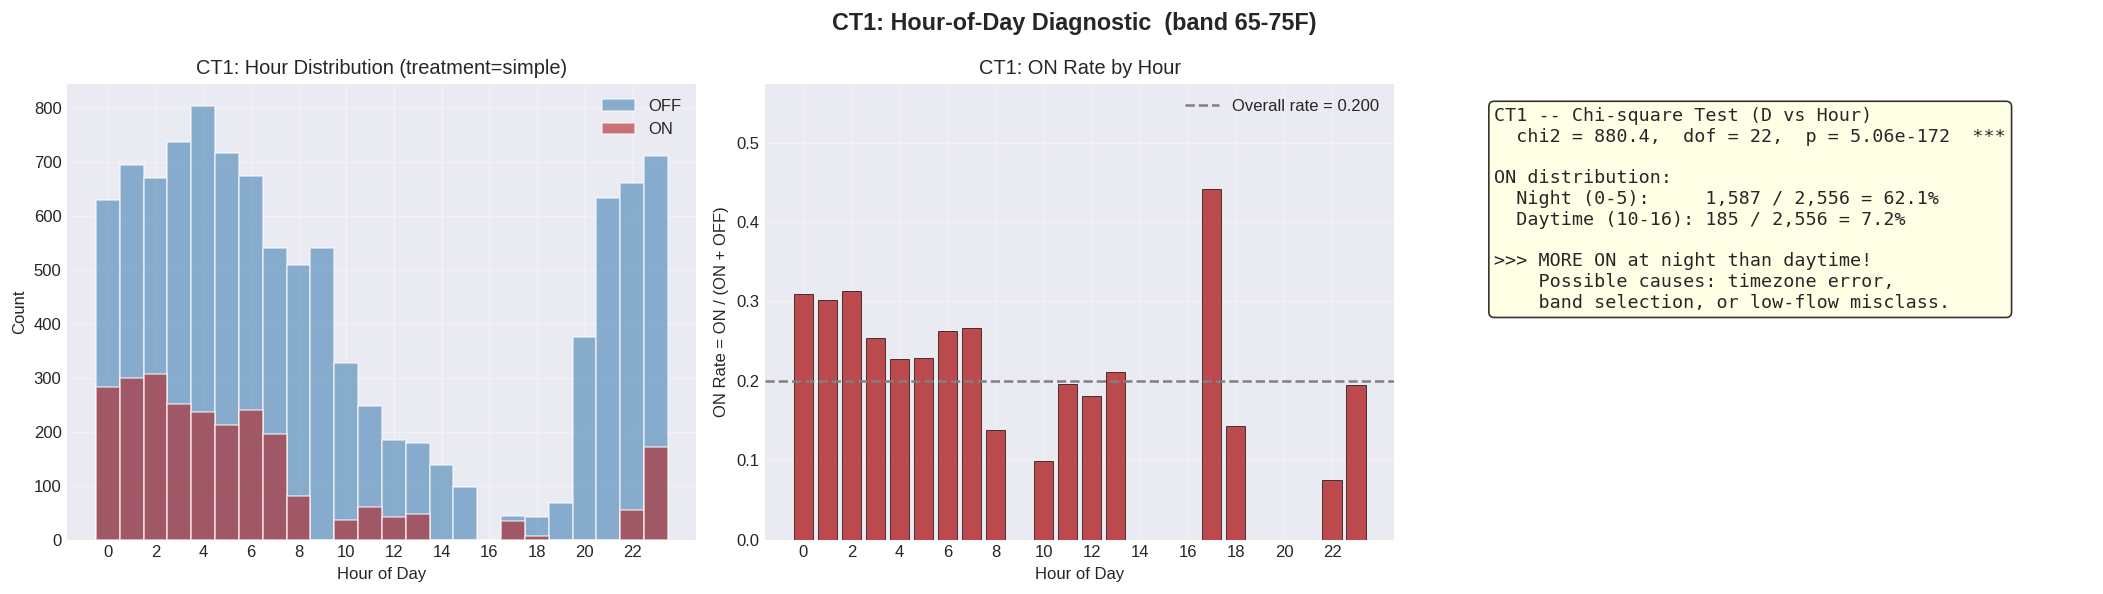


CT1: chi2=880.4, p=5.06e-172 ***
  Night ON: 1,587/2,556  Day ON: 185/2,556


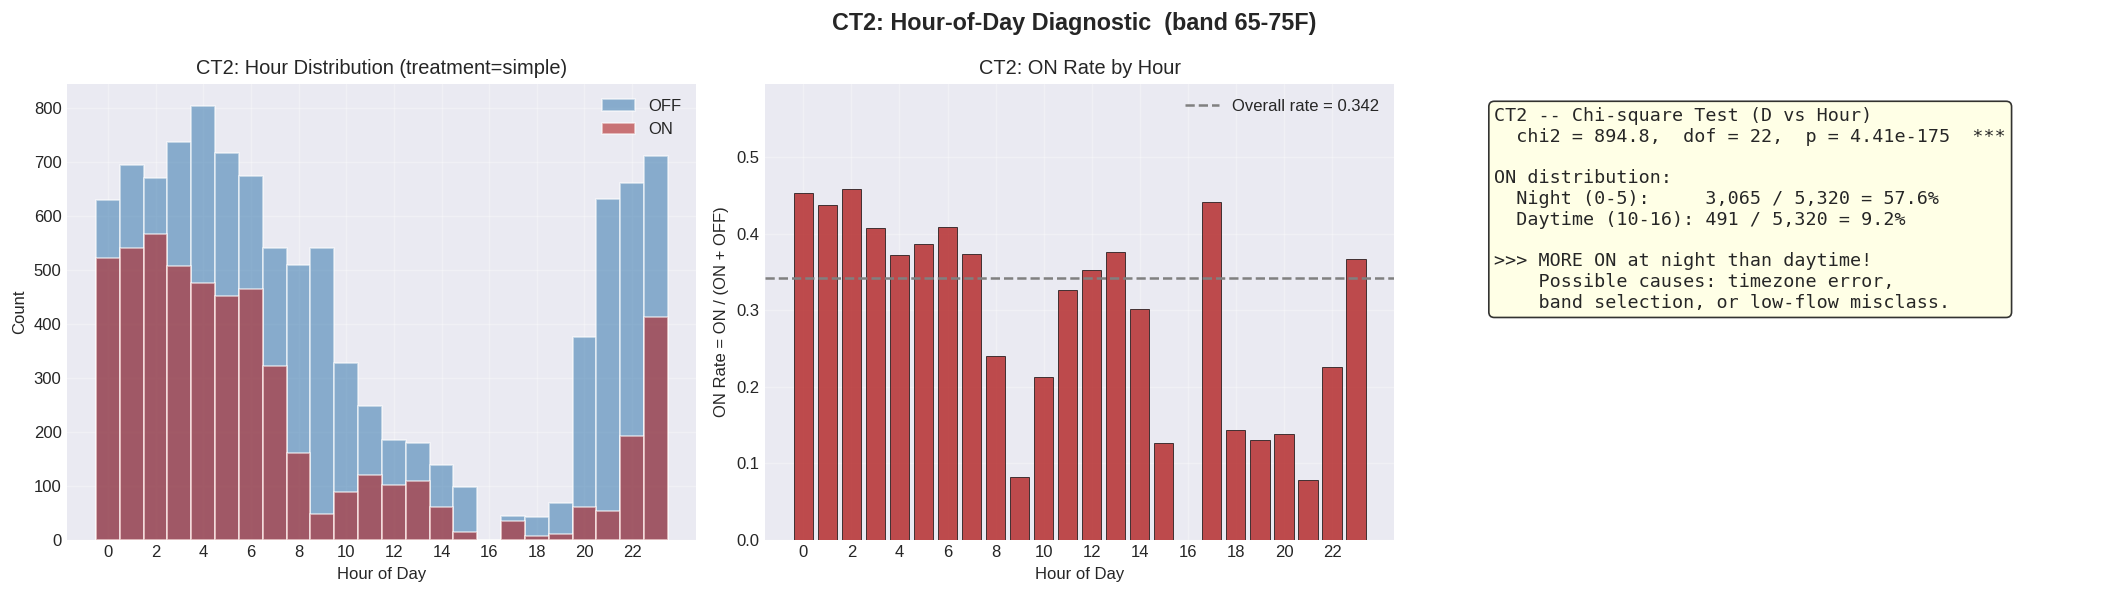


CT2: chi2=894.8, p=4.41e-175 ***
  Night ON: 3,065/5,320  Day ON: 491/5,320

Saved -> ./outputs/on_rate_by_hour.csv


In [11]:
# ============================================================================
# HOUR-OF-DAY DISTRIBUTION BY TREATMENT + ON-RATE + CHI-SQUARE
# ============================================================================
temp_lo, temp_hi = CONFIG['temp_band']
flow_col = CONFIG['flow_col']

on_rate_all = []

for label, frame in [('CT1', df_ct1), ('CT2', df_ct2)]:
    band = frame[frame[temp_col].between(temp_lo, temp_hi)].copy()
    band['D'] = assign_treatment(band[flow_col], CONFIG['treatment_mode'], CONFIG)
    band = band.dropna(subset=['D'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Panel 1: Stacked histogram ---
    ax = axes[0]
    h_off = band.loc[band['D'] == 0, 'hour']
    h_on  = band.loc[band['D'] == 1, 'hour']
    bins = np.arange(-0.5, 24.5, 1)
    ax.hist(h_off, bins=bins, alpha=0.6, label='OFF', color='steelblue', edgecolor='white')
    ax.hist(h_on,  bins=bins, alpha=0.6, label='ON',  color='firebrick', edgecolor='white')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}: Hour Distribution (treatment={CONFIG["treatment_mode"]})')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()

    # --- Panel 2: ON-rate by hour ---
    ax = axes[1]
    hourly = band.groupby('hour')['D'].agg(['sum', 'count'])
    hourly.columns = ['n_on', 'n_total']
    hourly['on_rate'] = hourly['n_on'] / hourly['n_total']
    hourly['turbine'] = label
    on_rate_all.append(hourly.reset_index())

    ax.bar(hourly.index, hourly['on_rate'], color='firebrick', edgecolor='black',
           linewidth=0.5, alpha=0.8)
    ax.axhline(band['D'].mean(), color='grey', linestyle='--', linewidth=1.5,
               label=f'Overall rate = {band["D"].mean():.3f}')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('ON Rate = ON / (ON + OFF)')
    ax.set_title(f'{label}: ON Rate by Hour')
    ax.set_xticks(range(0, 24, 2))
    ax.set_ylim(0, min(1.05, hourly['on_rate'].max() * 1.3))
    ax.legend()

    # --- Panel 3: Chi-square diagnostic text ---
    ax = axes[2]
    ax.axis('off')

    # Chi-square: is D independent of hour?
    ct = pd.crosstab(band['hour'], band['D'])
    if ct.shape[1] == 2 and ct.shape[0] >= 2:
        chi2, p_val, dof, _ = sp_stats.chi2_contingency(ct)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    else:
        chi2, p_val, dof, sig = np.nan, np.nan, np.nan, 'N/A'

    # Where is ON concentrated?
    night_hours = [0, 1, 2, 3, 4, 5]
    day_hours   = [10, 11, 12, 13, 14, 15, 16]
    n_on_night = band.loc[(band['D'] == 1) & (band['hour'].isin(night_hours))].shape[0]
    n_on_day   = band.loc[(band['D'] == 1) & (band['hour'].isin(day_hours))].shape[0]
    n_on_total = (band['D'] == 1).sum()

    lines = [
        f'{label} -- Chi-square Test (D vs Hour)',
        f'  chi2 = {chi2:.1f},  dof = {dof},  p = {p_val:.2e}  {sig}',
        '',
        f'ON distribution:',
        f'  Night (0-5):     {n_on_night:,} / {n_on_total:,} = {n_on_night/max(n_on_total,1)*100:.1f}%',
        f'  Daytime (10-16): {n_on_day:,} / {n_on_total:,} = {n_on_day/max(n_on_total,1)*100:.1f}%',
        '',
    ]
    if n_on_night > n_on_day and n_on_total > 0:
        lines.append('>>> MORE ON at night than daytime!')
        lines.append('    Possible causes: timezone error,')
        lines.append('    band selection, or low-flow misclass.')
    else:
        lines.append('ON is NOT concentrated at night.')

    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    fig.suptitle(f'{label}: Hour-of-Day Diagnostic  (band {temp_lo}-{temp_hi}F)',
                 fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print to console too
    print(f'\n{label}: chi2={chi2:.1f}, p={p_val:.2e} {sig}')
    print(f'  Night ON: {n_on_night:,}/{n_on_total:,}  Day ON: {n_on_day:,}/{n_on_total:,}')

# Save ON-rate by hour
on_rate_df = pd.concat(on_rate_all, ignore_index=True)
on_rate_df.to_csv(f"{CONFIG['output_dir']}/on_rate_by_hour.csv", index=False)
print(f"\nSaved -> {CONFIG['output_dir']}/on_rate_by_hour.csv")


---
## Step 5 -- Band Selection Effect

Does the chosen temperature band (e.g. 65-75F) naturally skew toward nighttime
because those temperatures only occur at night in summer? Compare the hour
distribution inside the band vs the full dataset.


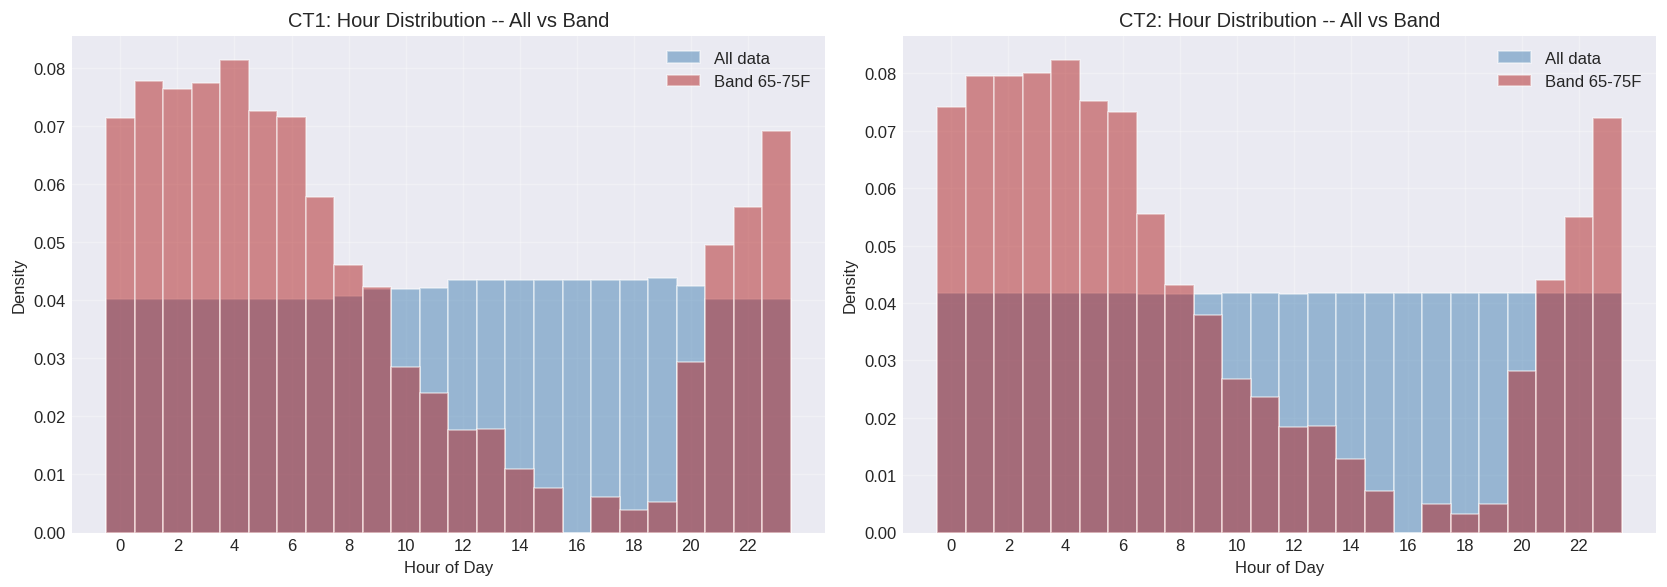

CT1:
  Band: 5,837/12,774 = 45.7% at night (0-5h)
  All:  8,640/35,820 = 24.1% at night (0-5h)
CT2:
  Band: 7,315/15,537 = 47.1% at night (0-5h)
  All:  11,158/44,612 = 25.0% at night (0-5h)


In [12]:
# ============================================================================
# BAND SELECTION EFFECT -- compare hour distribution in-band vs full data
# ============================================================================
temp_lo, temp_hi = CONFIG['temp_band']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, frame) in zip(axes, [('CT1', df_ct1), ('CT2', df_ct2)]):
    band = frame[frame[temp_col].between(temp_lo, temp_hi)]
    bins = np.arange(-0.5, 24.5, 1)

    # Normalize to density for fair comparison
    ax.hist(frame['hour'], bins=bins, density=True, alpha=0.5,
            color='steelblue', edgecolor='white', label='All data')
    ax.hist(band['hour'], bins=bins, density=True, alpha=0.5,
            color='firebrick', edgecolor='white', label=f'Band {temp_lo}-{temp_hi}F')

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Density')
    ax.set_title(f'{label}: Hour Distribution -- All vs Band')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()

plt.tight_layout()
plt.show()

# Quantify
for label, frame in [('CT1', df_ct1), ('CT2', df_ct2)]:
    band = frame[frame[temp_col].between(temp_lo, temp_hi)]
    night = band['hour'].isin([0,1,2,3,4,5]).sum()
    total = len(band)
    all_night = frame['hour'].isin([0,1,2,3,4,5]).sum()
    all_total = len(frame)
    print(f'{label}:')
    print(f'  Band: {night:,}/{total:,} = {night/max(total,1)*100:.1f}% at night (0-5h)')
    print(f'  All:  {all_night:,}/{all_total:,} = {all_night/max(all_total,1)*100:.1f}% at night (0-5h)')
    if total > 0 and night / total > 0.5:
        print(f'  >>> Band is naturally night-heavy! This explains ON concentration at night.')


---
## Step 6 -- Threshold / Multi-Modal Flow Diagnostic

If the simple threshold (>50 GPM) labels pump recirculation as ON, we will
see a bimodal flow distribution among the D=1 samples: a low-flow cluster
(50-200 GPM, recirculation) and a high-flow cluster (800+ GPM, real cooling).


CT1 (D=1, band 65-75F):
  Low flow (<200 GPM):  2 (0.1%)
  Mid flow (200-799):   513 (20.1%)
  High flow (>=800):    2,041 (79.9%)
CT2 (D=1, band 65-75F):
  Low flow (<200 GPM):  2 (0.0%)
  Mid flow (200-799):   3,280 (61.7%)
  High flow (>=800):    2,038 (38.3%)


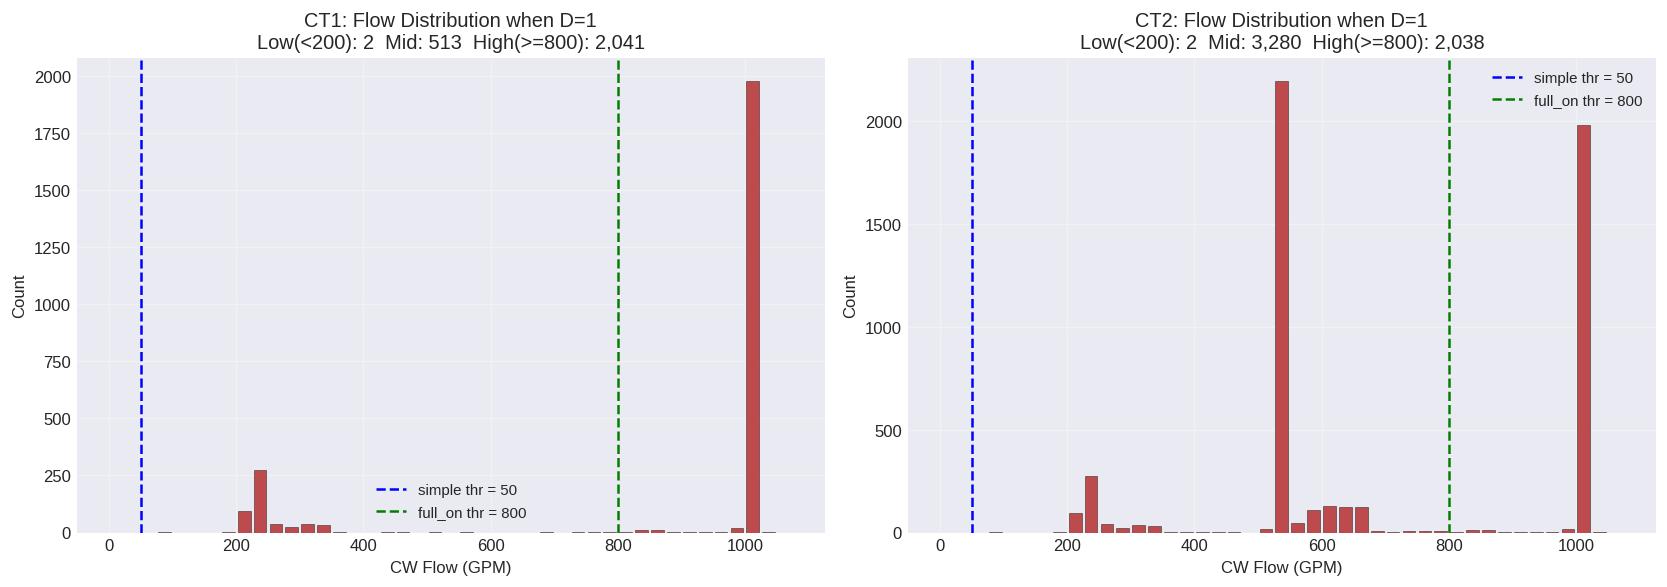


Saved -> ./outputs/flow_hist_on.csv


In [13]:
# ============================================================================
# FLOW DISTRIBUTION AMONG D=1 SAMPLES (in temp band)
# ============================================================================
temp_lo, temp_hi = CONFIG['temp_band']
flow_col = CONFIG['flow_col']

flow_hist_rows = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, frame) in zip(axes, [('CT1', df_ct1), ('CT2', df_ct2)]):
    band = frame[frame[temp_col].between(temp_lo, temp_hi)].copy()
    band['D'] = assign_treatment(band[flow_col], CONFIG['treatment_mode'], CONFIG)
    on_flow = band.loc[band['D'] == 1, flow_col].dropna()

    if len(on_flow) == 0:
        ax.text(0.5, 0.5, f'{label}: no ON samples', transform=ax.transAxes, ha='center')
        continue

    # Histogram with fine bins
    flow_bins = np.arange(0, on_flow.max() + 50, 25)
    counts, edges = np.histogram(on_flow, bins=flow_bins)
    centers = (edges[:-1] + edges[1:]) / 2

    ax.bar(centers, counts, width=20, color='firebrick', edgecolor='black',
           linewidth=0.3, alpha=0.8)

    # Mark thresholds
    ax.axvline(CONFIG['simple_threshold'], color='blue', linestyle='--',
               linewidth=1.5, label=f'simple thr = {CONFIG["simple_threshold"]}')
    ax.axvline(CONFIG['full_on'], color='green', linestyle='--',
               linewidth=1.5, label=f'full_on thr = {CONFIG["full_on"]}')

    # Classify clusters
    low_flow  = (on_flow < 200).sum()
    high_flow = (on_flow >= 800).sum()
    mid_flow  = len(on_flow) - low_flow - high_flow

    ax.set_xlabel('CW Flow (GPM)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}: Flow Distribution when D=1\n'
                 f'Low(<200): {low_flow:,}  Mid: {mid_flow:,}  High(>=800): {high_flow:,}')
    ax.legend(fontsize=9)

    # Record for CSV
    for c, cnt in zip(centers, counts):
        flow_hist_rows.append({'turbine': label, 'flow_bin_center': c, 'count': int(cnt)})

    # Console
    print(f'{label} (D=1, band {temp_lo}-{temp_hi}F):')
    print(f'  Low flow (<200 GPM):  {low_flow:,} ({low_flow/len(on_flow)*100:.1f}%)')
    print(f'  Mid flow (200-799):   {mid_flow:,} ({mid_flow/len(on_flow)*100:.1f}%)')
    print(f'  High flow (>=800):    {high_flow:,} ({high_flow/len(on_flow)*100:.1f}%)')
    if low_flow > high_flow:
        print(f'  >>> MAJORITY of ON samples are LOW-FLOW -- threshold may be too low!')

plt.tight_layout()
plt.show()

flow_hist_df = pd.DataFrame(flow_hist_rows)
flow_hist_df.to_csv(f"{CONFIG['output_dir']}/flow_hist_on.csv", index=False)
print(f"\nSaved -> {CONFIG['output_dir']}/flow_hist_on.csv")


---
## Step 7 -- Cross-Check Across Treatment Definitions

Compare hour-of-day distributions using all three treatment definitions.
If simple/deadband show night-concentration but full_vs_off does NOT,
it strongly suggests the low threshold is misclassifying pump recirculation.


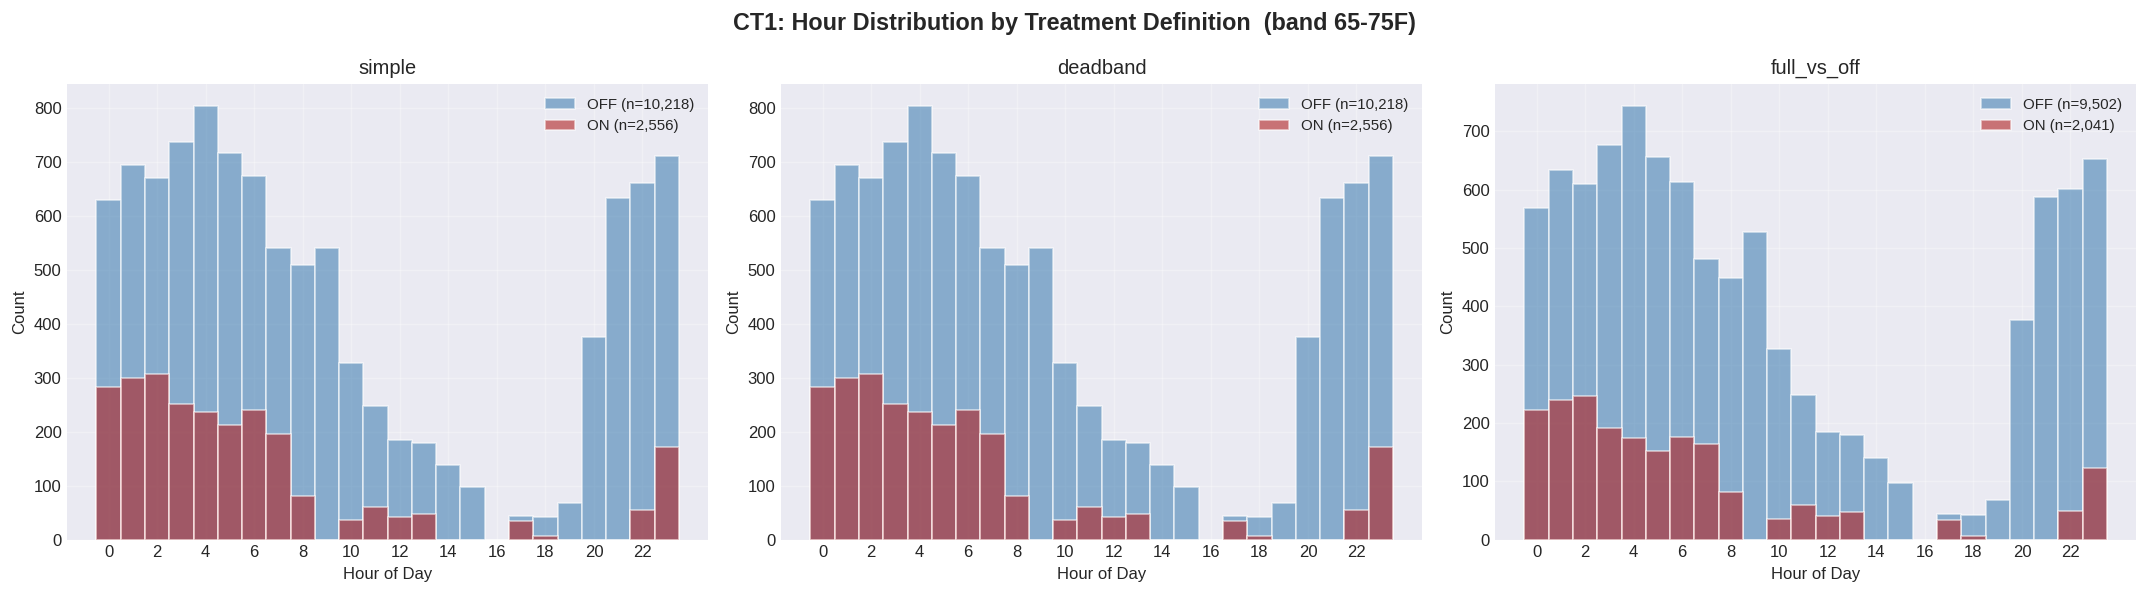


CT1 -- Night fraction (hours 0-5) among ON samples:
  simple         : 62.1%  <<< night-concentrated!
  deadband       : 62.1%  <<< night-concentrated!
  full_vs_off    : 60.0%  <<< night-concentrated!

  >>> DIAGNOSIS: Night concentration persists across ALL definitions.
      Likely cause: band selection effect (65-75F is nighttime in summer)
      or timezone error. Check Steps 2 and 5.


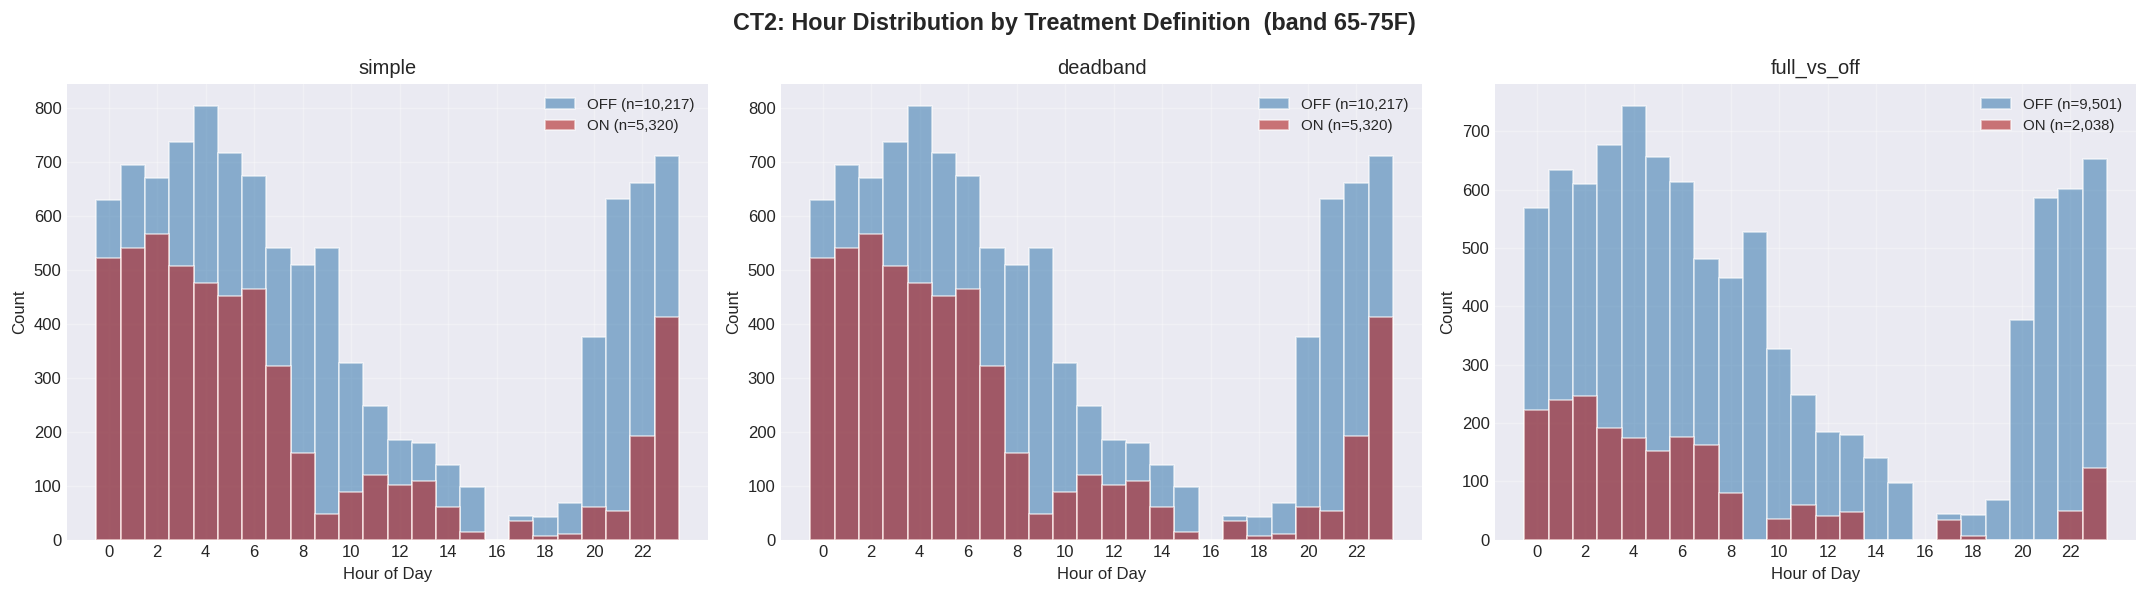


CT2 -- Night fraction (hours 0-5) among ON samples:
  simple         : 57.6%  <<< night-concentrated!
  deadband       : 57.6%  <<< night-concentrated!
  full_vs_off    : 60.1%  <<< night-concentrated!

  >>> DIAGNOSIS: Night concentration persists across ALL definitions.
      Likely cause: band selection effect (65-75F is nighttime in summer)
      or timezone error. Check Steps 2 and 5.


In [14]:
# ============================================================================
# CROSS-CHECK: simple vs deadband vs full_vs_off
# ============================================================================
temp_lo, temp_hi = CONFIG['temp_band']
flow_col = CONFIG['flow_col']
modes = ['simple', 'deadband', 'full_vs_off']

for label, frame in [('CT1', df_ct1), ('CT2', df_ct2)]:
    band = frame[frame[temp_col].between(temp_lo, temp_hi)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    night_fracs = {}

    for ax, mode in zip(axes, modes):
        band_m = band.copy()
        band_m['D'] = assign_treatment(band_m[flow_col], mode, CONFIG)
        band_m = band_m.dropna(subset=['D'])

        h_off = band_m.loc[band_m['D'] == 0, 'hour']
        h_on  = band_m.loc[band_m['D'] == 1, 'hour']
        bins = np.arange(-0.5, 24.5, 1)

        ax.hist(h_off, bins=bins, alpha=0.6, label=f'OFF (n={len(h_off):,})',
                color='steelblue', edgecolor='white')
        ax.hist(h_on,  bins=bins, alpha=0.6, label=f'ON (n={len(h_on):,})',
                color='firebrick', edgecolor='white')

        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Count')
        ax.set_title(f'{mode}')
        ax.set_xticks(range(0, 24, 2))
        ax.legend(fontsize=9)

        # Night fraction for ON
        n_on = len(h_on)
        if n_on > 0:
            night_on = h_on.isin([0,1,2,3,4,5]).sum()
            night_fracs[mode] = night_on / n_on
        else:
            night_fracs[mode] = np.nan

    fig.suptitle(f'{label}: Hour Distribution by Treatment Definition  '
                 f'(band {temp_lo}-{temp_hi}F)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print comparison
    print(f'\n{label} -- Night fraction (hours 0-5) among ON samples:')
    for mode in modes:
        nf = night_fracs[mode]
        flag = '  <<< night-concentrated!' if nf > 0.4 else ''
        print(f'  {mode:15s}: {nf:.1%}{flag}')

    # Diagnosis
    if (night_fracs.get('simple', 0) > 0.4 and
        night_fracs.get('full_vs_off', 1) < 0.3):
        print(f'\n  >>> DIAGNOSIS: Night concentration DISAPPEARS with full_vs_off.')
        print(f'      This means the simple threshold ({CONFIG["simple_threshold"]} GPM) is')
        print(f'      misclassifying pump recirculation / partial flow as cooling ON.')
        print(f'      Recommendation: use full_vs_off or raise threshold to ~800 GPM.')
    elif all(night_fracs.get(m, 0) > 0.4 for m in modes):
        print(f'\n  >>> DIAGNOSIS: Night concentration persists across ALL definitions.')
        print(f'      Likely cause: band selection effect (65-75F is nighttime in summer)')
        print(f'      or timezone error. Check Steps 2 and 5.')


---
## Summary & Conclusions


In [15]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print('=' * 72)
print('FILES SAVED')
print('=' * 72)
for f in ['overlap_stats.csv', 'on_rate_by_hour.csv', 'flow_hist_on.csv']:
    fp = f"{CONFIG['output_dir']}/{f}"
    if os.path.exists(fp):
        print(f'  OK      {fp}')
    else:
        print(f'  MISSING {fp}')


FILES SAVED
  OK      ./outputs/overlap_stats.csv
  OK      ./outputs/on_rate_by_hour.csv
  OK      ./outputs/flow_hist_on.csv


---
## Interpretation Guide

- **If peak temperature occurs at night (Step 2):** timestamps are likely in UTC. Set `CONFIG['timezone_mode'] = 'force_utc'` and re-run.
- **If the temp band (e.g. 65-75F) is overwhelmingly nighttime (Step 5):** the band itself selects for nighttime observations. This is expected in summer and does NOT indicate a data error. Raise the band (e.g. 85-95F) for daytime analysis.
- **If D=1 samples are dominated by low-flow (<200 GPM) in Step 6:** the simple threshold (50 GPM) is too low and captures pump recirculation, not actual inlet air cooling. Use `full_vs_off` treatment.
- **If night-concentration disappears under `full_vs_off` (Step 7):** confirms threshold misclassification. Low-flow pump circulation happens at night; real cooling (>=800 GPM) follows a different pattern.
- **If night-concentration persists under all treatment definitions:** the cause is band selection or timezone, not threshold.
- **Recommended next step:** switch to `full_vs_off` treatment and use the 85-95F band in the causal regression notebook for the cleanest causal contrast.
- **If timezone was the issue:** after correcting, re-run this notebook to confirm the diurnal pattern is restored and ON rate is not anomalously nocturnal.
- **Final note:** some nighttime cooling is physically possible (pre-cooling thermal mass), but if >50% of ON is at night under `simple` threshold, misclassification is the most likely explanation.
